## Imports

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from xgboost import XGBRegressor
import joblib

# from sklearn.linear_model import LogisticRegression
# from sklearn.ensemble import RandomForestClassifier
#from xgboost import XGBClassifier



## Config

In [2]:
URGENCY_MAP = {"منخفض": 1, "متوسط": 2, "عاجل": 3}

AVAILABILITY_MAP = {
    "اليوم": 3,
    "غدا": 2,
    "خلال أسبوع": 1
}


## Load & Sample Data

In [3]:
# Load data
requests_df = pd.read_csv("../Data/requests.csv")
donors_df = pd.read_csv("../Data/donors.csv")

# Take sample
req_sample = requests_df.sample(5000, random_state=42)
don_sample = donors_df.sample(5000, random_state=42)

print("Requests sample:", req_sample.shape)
print("Donors sample:", don_sample.shape)

Requests sample: (5000, 8)
Donors sample: (5000, 6)


## Generate Request–Donor Pairs (Cross Join)

In [4]:
pairs = []

for _, req in req_sample.iterrows():
    sampled_donors = don_sample.sample(5, random_state=42)  # بس 5 لكل طلب

    for _, donor in sampled_donors.iterrows():
        row = {}

        # request
        row.update(req.to_dict())

        # donor
        row["donation_type"] = donor["donation_type"]
        row["available_quantity"] = donor["available_quantity"]
        row["location_donor"] = donor["location_donor"]
        row["availability"] = donor["availability"]
        row["Trust_Score"] = donor["Trust_Score"]

        pairs.append(row)

pairs = pd.DataFrame(pairs)

print("Total pairs:", len(pairs))
pairs.head()

Total pairs: 25000


,request_id,need_type,needed_quantity,location_requester,urgency,age,family_members,is_family,donation_type,available_quantity,location_donor,availability,Trust_Score
0,1502,علاج,10,بورسعيد,متوسط,37,5,1,علاج,1,الجيزة,خلال أسبوع,81
1,1502,علاج,10,بورسعيد,متوسط,37,5,1,علاج,5,بورسعيد,اليوم,50
2,1502,علاج,10,بورسعيد,متوسط,37,5,1,علاج,4,الإسكندرية,غدا,42
3,1502,علاج,10,بورسعيد,متوسط,37,5,1,علاج,8,المنصورة,خلال أسبوع,40
4,1502,علاج,10,بورسعيد,متوسط,37,5,1,لبس,8,المنصورة,خلال أسبوع,60


## GPS

In [5]:
# from geopy.geocoders import Nominatim
# from geopy.distance import geodesic

# geolocator = Nominatim(user_agent="matching_app")

# location_cache = {}

# def get_coordinates(location_name):
#     if location_name in location_cache:
#         return location_cache[location_name]

#     location = geolocator.geocode(location_name)

#     if location:
#         coords = (location.latitude, location.longitude)
#         location_cache[location_name] = coords
#         return coords

#     return None

# def compute_distance_km(row, donor):

#     if "lat" in row and "lon" in row:
#         loc1 = (row["lat"], row["lon"])
#     else:
#         loc1 = get_coordinates(row["location_requester"])

#     if "lat" in donor and "lon" in donor:
#         loc2 = (donor["lat"], donor["lon"])
#     else:
#         loc2 = get_coordinates(donor["location_donor"])


#     return geodesic(loc1, loc2).km

## Feature Engineering

In [6]:
# 1. Matching features
pairs["need_match"] = (pairs["need_type"] == pairs["donation_type"]).astype(int)
pairs["location_match"] = (pairs["location_requester"] == pairs["location_donor"]).astype(int)

pairs["same_location"] = (pairs["location_requester"] == pairs["location_donor"]).astype(int)

# 2. Scores
pairs["urgency_score"] = pairs["urgency"].map(URGENCY_MAP)
pairs["availability_score"] = pairs["availability"].map(AVAILABILITY_MAP)

# 3. Quantity fit (continuous better than binary)
pairs["quantity_fit"] = (pairs["available_quantity"] / pairs["needed_quantity"]).clip(upper=1)
pairs["quantity_fit"] = np.sqrt(pairs["quantity_fit"])

# 4. Trust
pairs["trust_score"] = pairs["Trust_Score"] / 100

# # 5. Distance
# pairs["distance_km"] = pairs.apply(
#     lambda row: compute_distance_km(
#         {"location_requester": row["location_requester"]},
#         {"location_donor": row["location_donor"]}
#     ),
#     axis=1
# )
# # normalize distance
# pairs["distance_km"] = pairs["distance_km"] / 1000

In [7]:
FEATURE_COLS = [
    "need_match",
    "location_match",
    "urgency_score",
    "availability_score",
    "quantity_fit",
    "trust_score"
]

## Label Generation (Rule-based + Noise)

In [8]:
score = (
    pairs["need_match"] * 1.5+
    pairs["location_match"] * 2 +
    pairs["urgency_score"] * 2 +
    pairs["availability_score"] * 0.5 +
    pairs["quantity_fit"] * 2 +
    pairs["trust_score"] * 1

)
noise = np.random.normal(0,0.5, len(pairs))
pairs["final_score"] = score + noise
# نحول لـ label
threshold = pairs["final_score"].quantile(0.6)
pairs["label"] = (pairs["final_score"] > threshold).astype(int)

print(pairs["final_score"].describe())

count    25000.000000
mean         8.065077
std          2.010113
min          2.497100
25%          6.591179
50%          8.028732
75%          9.497142
max         14.513736
Name: final_score, dtype: float64


## Train/Test

In [9]:
X = pairs[FEATURE_COLS]
y = pairs["final_score"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (20000, 6)
Test size: (5000, 6)


## Train Models

XGBoost (Final Model)

In [10]:
model = XGBRegressor(
    n_estimators=500,
    max_depth=8,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)
model.fit(X_train, y_train, verbose=True)


,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


## Model Evaluation 

In [11]:
from sklearn.metrics import mean_squared_error

preds = model.predict(X_test)
mse = mean_squared_error(y_test, preds)

print(f"MSE: {mse:.4f}")

MSE: 0.2461


In [14]:
import joblib

joblib.dump(model, "model.pkl")

['model.pkl']

In [ ]:
# # Predictions
# y_pred = xgb_model.predict(X_test)
# y_proba = xgb_model.predict_proba(X_test)[:, 1]
# # Metrics
# accuracy = accuracy_score(y_test, y_pred)
# auc = roc_auc_score(y_test, y_proba)

# # Classification report as table
# report = classification_report(y_test, y_pred, output_dict=True)
# report_df = pd.DataFrame(report).transpose()


# report_df = report_df.loc[["0", "1"]]
# report_df = report_df.round(2)
# accuracy_df = pd.DataFrame({
#     "Model": ["XGBoost"],
#     "Accuracy": [accuracy],
#     "AUC": [auc]
# })

# print("Model Performance Summary")
# display(accuracy_df.style.format({"Accuracy": "{:.2%}", "AUC": "{:.3f}"}))
# display(report_df)

## Priority-Based Matching Function

In [15]:
def match_requests_priority(model, requests_df, donor_row, k=3):
    candidates = requests_df.copy()

    # 1. Matching
    candidates["need_match"] = (candidates["need_type"] == donor_row["donation_type"]).astype(int)

    # 2. Scores
    candidates["urgency_score"] = candidates["urgency"].map(URGENCY_MAP)
    candidates["availability_score"] = AVAILABILITY_MAP[donor_row["availability"]]

    # 3. Quantity
    candidates["quantity_fit"] = (
        donor_row["available_quantity"] / candidates["needed_quantity"]
    ).clip(upper=1)


    # # 4. Distance
    candidates["location_match"] = (candidates["location_requester"] == donor_row["location"]).astype(int)
    candidates["trust_score"] = donor_row.get("trust_score", 0.5)
    # candidates["distance_km"] = candidates.apply(
    #     lambda row: compute_distance_km(row, donor_row),
    #     axis=1
    # )
    # candidates["distance_km"] = candidates["distance_km"] / 1000

    # قريب = match
    #candidates["location_match"] = (candidates["distance_km"] < 0.05).astype(int)

    # Filtering
    candidates = candidates[
        (candidates["need_match"] == 1)
    ]

    # Prediction
    X = candidates[FEATURE_COLS]
    candidates["predicted_score"] = model.predict(X)

    # Ranking
    candidates = candidates.sort_values(by="predicted_score", ascending=False)


    return candidates.head(k)[[
        "need_type",
        "urgency",
        "location_requester",
        "predicted_score"

    ]].to_dict(orient="records")


## Test on New Data

In [16]:
donor_test = {
    "donation_type": "أكل",
    "available_quantity": 2,
    "availability": "اليوم",
    "location": "القاهرة",
    "trust_score": 0.8
}

test_requests = pd.DataFrame([
    # قليل جدا بس عاجل
    {"need_type": "أكل", "needed_quantity": 1, "location_requester": "القاهرة", "urgency": "عاجل", "family_members": 1},

    # perfect quantity بس متوسط
    {"need_type": "أكل", "needed_quantity": 2, "location_requester": "القاهرة", "urgency": "متوسط", "family_members": 1},
    {"need_type": "أكل", "needed_quantity": 6, "location_requester": "سوهاج", "urgency": "متوسط", "family_members": 6},
])
results = match_requests_priority(model, test_requests, donor_test)
results = pd.DataFrame(results)

if results.empty:
    print("No suitable matches found for this donor.")
    
else: display(
    results.reindex(columns=[
        "need_type",
        "urgency",
        "location_requester",
        "predicted_score",
              
    ]).style.format({
        "predicted_score": "{:.2f}",
        "final_score": "{:.2f}"
    })
)           
    

,need_type,urgency,location_requester,predicted_score
0,أكل,عاجل,القاهرة,13.46
1,أكل,متوسط,القاهرة,11.30
2,أكل,متوسط,سوهاج,8.48


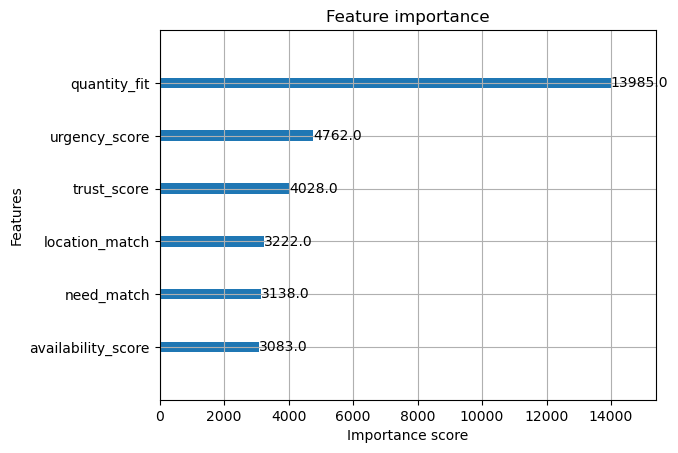

In [17]:
import matplotlib.pyplot as plt
from xgboost import plot_importance

plot_importance(model)
plt.show()